Импорт библиотек, функция из задачи, данные из аналитического этапа

In [1]:
import math
import time
from typing import Callable, Tuple, List, Optional
import numpy as np
import matplotlib.pyplot as plt

Function2D = Callable[[float, float], float]
Grad2D = Callable[[float, float], Tuple[float, float]]

def f_main(x: float, y: float) -> float:
    return 6.0 * x * y - x**3 - y**3

def grad_f_main(x: float, y: float) -> Tuple[float, float]:
    gx = 6.0 * y - 3.0 * x**2
    gy = 6.0 * x - 3.0 * y**2
    return gx, gy

def numerical_grad(f: Function2D, x: float, y: float, h: float = 1e-6) -> Tuple[float, float]:
    fxph = f(x + h, y)
    fxmh = f(x - h, y)
    gx = (fxph - fxmh) / (2*h)
    fyph = f(x, y + h)
    fymh = f(x, y - h)
    gy = (fyph - fymh) / (2*h)
    return gx, gy


функции: Розенброк, Растригин, функция Бут, и плохо масштабированная функция. Для этих функций по возможности будут аналитические градиенты

In [2]:
def f_rosenbrock(x: float, y: float) -> float:
    return (1 - x)**2 + 100.0 * (y - x**2)**2

def grad_rosenbrock(x: float, y: float) -> Tuple[float, float]:
    gx = -2.0*(1 - x) - 400.0*x*(y - x**2)
    gy = 200.0*(y - x**2)
    return gx, gy

def f_rastrigin(x: float, y: float, A: float = 10.0) -> float:
    return A*2 + (x**2 - A * np.cos(2*np.pi*x)) + (y**2 - A * np.cos(2*np.pi*y))

def grad_rastrigin(x: float, y: float, A: float = 10.0) -> Tuple[float, float]:
    gx = 2.0*x + 2.0*np.pi*A*np.sin(2.0*np.pi*x)
    gy = 2.0*y + 2.0*np.pi*A*np.sin(2.0*np.pi*y)
    return gx, gy

def f_booth_like(x: float, y: float) -> float:
    return (x**2 + y - 11.0)**2 + (x + y**2 - 7.0)**2

def grad_booth_like(x: float, y: float) -> Tuple[float, float]:
    gx = 2.0*(x**2 + y - 11.0)*2.0*x + 2.0*(x + y**2 - 7.0)*1.0
    gy = 2.0*(x**2 + y - 11.0)*1.0 + 2.0*(x + y**2 - 7.0)*2.0*y
    return gx, gy

def f_bad_scale(x: float, y: float) -> float:
    return (1000.0 * x)**2 + (0.001 * y)**2

def grad_bad_scale(x: float, y: float) -> Tuple[float, float]:
    gx = 2.0 * (1000.0**2) * x
    gy = 2.0 * (0.001**2) * y
    return gx, gy

def f_easom(x: float, y: float) -> float:
    return -np.cos(x) * np.cos(y) * np.exp(-((x - np.pi)**2 + (y - np.pi)**2))

def f_taskf(x: float, y: float) -> float:
    return np.sin(x**2 - 3.0*y**2 + 3.0) * np.cos(2.0*x + 1.0 + np.exp(y))


Eggholder — важная функция, градиент определяю программно 

In [3]:
def f_eggholder(x: float, y: float) -> float:
    term1 = -(y + 47.0) * np.sin(np.sqrt(abs(x/2.0 + (y + 47.0))))
    term2 = -x * np.sin(np.sqrt(abs(x - (y + 47.0))))
    return term1 + term2


Здесь правила выбора шага: постоянный шаг, убывающий шаг и backtracking Armijo(динамический выдор длины шага в гдрспуске). Также есть backtracking для произвольного направления, который используется в сопряжённых методах.

In [4]:
def alpha_const(f: Function2D, grad_f: Grad2D,
                k: int, x: float, y: float, gx: float, gy: float,
                alpha0: float = 0.05) -> float:
    return alpha0

def alpha_diminishing(f: Function2D, grad_f: Grad2D,
                      k: int, x: float, y: float, gx: float, gy: float,
                      alpha0: float = 0.1) -> float:
    return alpha0 / (1.0 + k)

def alpha_backtracking(f: Function2D, grad_f: Grad2D,
                       k: int, x: float, y: float, gx: float, gy: float,
                       alpha0: float = 1.0, beta: float = 0.5, c: float = 1e-4) -> float:
    alpha = alpha0
    fx = f(x, y)
    grad_norm_sq = gx*gx + gy*gy
    if grad_norm_sq == 0.0:
        return 0.0
    while True:
        x_new = x - alpha * gx
        y_new = y - alpha * gy
        f_new = f(x_new, y_new)
        if f_new <= fx - c * alpha * grad_norm_sq:
            break
        alpha *= beta
        if alpha < 1e-12:
            break
    return alpha

def alpha_backtracking_dir_impl(f: Function2D,
                                grad_f: Optional[Grad2D],
                                x: float, y: float,
                                gx: float, gy: float,
                                dx: float, dy: float,
                                alpha0: float = 1.0,
                                beta: float = 0.5,
                                c: float = 1e-4) -> float:
    alpha = alpha0
    fx = f(x, y)
    grad_dot_d = gx*dx + gy*dy
    if grad_dot_d >= 0:
        return 0.0
    while True:
        x_new = x + alpha * dx
        y_new = y + alpha * dy
        f_new = f(x_new, y_new)
        if f_new <= fx + c * alpha * grad_dot_d:
            break
        alpha *= beta
        if alpha < 1e-12:
            break
    return alpha


Точный одномерный поиск шага реализован методом золотого сечения. Он минимизирует функцию вдоль заданного направления.

In [5]:
def line_search_alpha_golden(f: Function2D,
                             x: float, y: float,
                             dx: float, dy: float,
                             a0: float = 0.0, b0: float = 1.0,
                             tol: float = 1e-6, max_iter: int = 100) -> float:
    def phi(a):
        return f(x + a*dx, y + a*dy)
    a, b = a0, b0
    fa, fb = phi(a), phi(b)
    attempts = 0
    while fb < fa and attempts < 40:
        a = b
        fa = fb
        b = b * 2.0 if b != 0.0 else 1.0
        fb = phi(b)
        attempts += 1
        if b > 1e6:
            break
    gr = (math.sqrt(5) - 1) / 2
    c = b - gr*(b - a)
    d = a + gr*(b - a)
    fc = phi(c)
    fd = phi(d)
    it = 0
    while (b - a) > tol and it < max_iter:
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - gr*(b - a)
            fc = phi(c)
        else:
            a, c, fc = c, d, fd
            d = a + gr*(b - a)
            fd = phi(d)
        it += 1
    alpha_opt = (a + b) / 2.0
    return alpha_opt


Общий градиентный спуск с опцией численного градиента и защитой от разлёта. Если alpha_rule=None, используется точечный поиск по антиградиенту

In [ ]:
def gradient_descent(f: Function2D,
                     grad_f: Optional[Grad2D],
                     x0: float, y0: float,
                     alpha_rule: Optional[Callable] = alpha_const,
                     eps: float = 1e-6,
                     max_iter: int = 100000,
                     use_numerical_grad: bool = False,
                     record_every: int = 1,
                     x_min: float = -5.0,
                     x_max: float = 5.0,
                     y_min: float = -5.0,
                     y_max: float = 5.0
                     ) -> Tuple[float, float, List[Tuple[float, float, float]]]:
    x, y = x0, y0
    history: List[Tuple[float, float, float]] = [(x, y, f(x, y))]
    for k in range(max_iter):
        gx, gy = numerical_grad(f, x, y) if use_numerical_grad or grad_f is None else grad_f(x, y)
        if math.hypot(gx, gy) < eps:
            break
        alpha = line_search_alpha_golden(f, x, y, -gx, -gy, a0=0.0, b0=1.0, tol=1e-6) if alpha_rule is None else alpha_rule(f, grad_f, k, x, y, gx, gy)
        x_new = max(x_min, min(x - alpha * gx, x_max))
        y_new = max(y_min, min(y - alpha * gy, y_max))
        x, y = x_new, y_new
        
        if (k % record_every) == 0:
            history.append((x, y, f(x, y)))
        if abs(x) > 1e6 or abs(y) > 1e6:
            print("Достигнут предел, функция неограничена, остановка")
            break
    return x, y, history


Сопряжённые методы Fletcher–Reeves и Polak–Ribiere. Для надёжности используется backtracking по направлению, при неудаче применяется золотое сечение.

In [7]:
def conjugate_gradient(f: Function2D,
                       grad_f: Optional[Grad2D],
                       x0: float, y0: float,
                       eps: float = 1e-6,
                       max_iter: int = 100000,
                       variant: str = "FR",
                       use_numerical_grad: bool = False) -> Tuple[float, float, List[Tuple[float, float, float]]]:
    x, y = x0, y0
    if use_numerical_grad:
        gx, gy = numerical_grad(f, x, y)
    else:
        if grad_f is None:
            gx, gy = numerical_grad(f, x, y)
        else:
            gx, gy = grad_f(x, y)
    dx, dy = -gx, -gy
    history = [(x, y, f(x, y))]
    for k in range(max_iter):
        grad_norm = math.hypot(gx, gy)
        if grad_norm < eps:
            break
        alpha_val = alpha_backtracking_dir_impl(f, grad_f, x, y, gx, gy, dx, dy)
        if alpha_val <= 0.0:
            alpha_val = line_search_alpha_golden(f, x, y, dx, dy, 0.0, 1.0, tol=1e-6)
        x_new = x + alpha_val * dx
        y_new = y + alpha_val * dy
        if use_numerical_grad:
            gx_new, gy_new = numerical_grad(f, x_new, y_new)
        else:
            if grad_f is None:
                gx_new, gy_new = numerical_grad(f, x_new, y_new)
            else:
                gx_new, gy_new = grad_f(x_new, y_new)
        if variant.upper() == "FR":
            numerator = gx_new*gx_new + gy_new*gy_new
            denom = gx*gx + gy*gy
            beta = numerator / denom if denom != 0.0 else 0.0
        elif variant.upper() == "PR":
            dgx = gx_new - gx
            dgy = gy_new - gy
            numerator = gx_new * dgx + gy_new * dgy
            denom = gx*gx + gy*gy
            beta = numerator / denom if denom != 0.0 else 0.0
            beta = max(beta, 0.0)
        else:
            raise ValueError("Unknown variant for conjugate_gradient: use 'FR' or 'PR'")
        dx = -gx_new + beta * dx
        dy = -gy_new + beta * dy
        x, y = x_new, y_new
        gx, gy = gx_new, gy_new
        history.append((x, y, f(x, y)))
    return x, y, history


Визуализация

In [8]:
def plot_surface_and_contours(f: Function2D, xlim: Tuple[float,float], ylim: Tuple[float,float],
                              nx: int = 300, ny: int = 300,
                              mark_points: Optional[List[Tuple[float,float,str]]] = None,
                              title: str = "Функция и линии уровня"):
    X = np.linspace(xlim[0], xlim[1], nx)
    Y = np.linspace(ylim[0], ylim[1], ny)
    XX, YY = np.meshgrid(X, Y)
    ZZ = np.vectorize(f)(XX, YY)
    fig = plt.figure(figsize=(12,5))
    ax1 = fig.add_subplot(1,2,1, projection='3d')
    ax1.plot_surface(XX, YY, ZZ, cmap='viridis', alpha=0.9)
    ax1.set_title(title + " (3D)")
    ax1.set_xlabel("x"); ax1.set_ylabel("y")
    ax2 = fig.add_subplot(1,2,2)
    cs = ax2.contour(XX, YY, ZZ, levels=30)
    plt.colorbar(cs, ax=ax2)
    ax2.set_title(title + " (contour)")
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    if mark_points:
        for (px, py, style) in mark_points:
            ax2.scatter([px], [py], color=style, s=60)
    plt.show()

def plot_trajectory_on_contour(f: Function2D, history: List[Tuple[float,float,float]],
                               xlim=(-1,4), ylim=(-1,4), title="Траектория"):
    X = np.linspace(xlim[0], xlim[1], 300)
    Y = np.linspace(ylim[0], ylim[1], 300)
    XX, YY = np.meshgrid(X, Y)
    ZZ = np.vectorize(f)(XX, YY)
    xs = [p[0] for p in history]
    ys = [p[1] for p in history]
    plt.figure(figsize=(7,6))
    plt.contour(XX, YY, ZZ, levels=30)
    plt.plot(xs, ys, '-o', markersize=3)
    plt.scatter([xs[0]],[ys[0]], color='green', label='start')
    plt.scatter([xs[-1]],[ys[-1]], color='red', label='end')
    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")
    plt.legend()
    plt.show()

def print_summary(name: str, x: float, y: float, history: List[Tuple[float,float,float]]):
    print(f"{name}: итераций={len(history)-1}, x={x:.6f}, y={y:.6f}, f={history[-1][2]:.6f}")


Главный Тест: тестирование методов на основной функции, автотест по разным eps и тестирование на дополнительных функциях

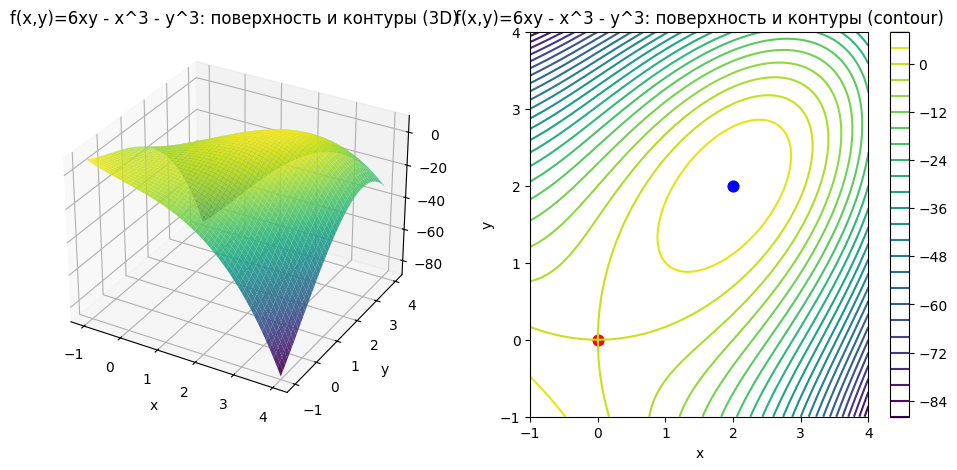

GradDesc constant (alpha=0.01): итераций=20000, x=4.000000, y=-1.000000, f=-87.000000


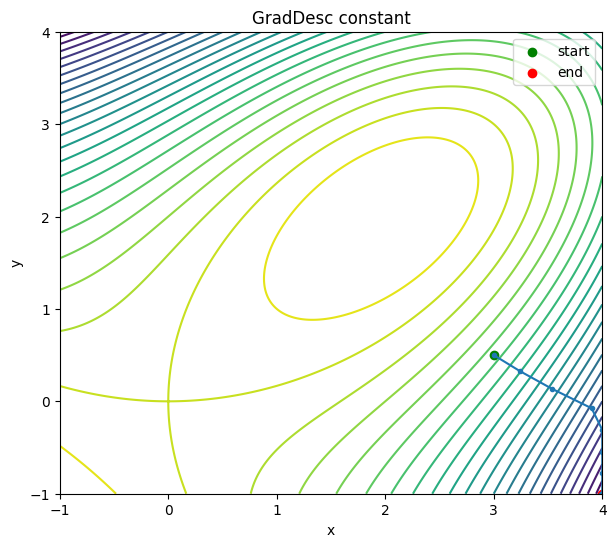

GradDesc diminishing: итераций=20000, x=4.000000, y=-1.000000, f=-87.000000


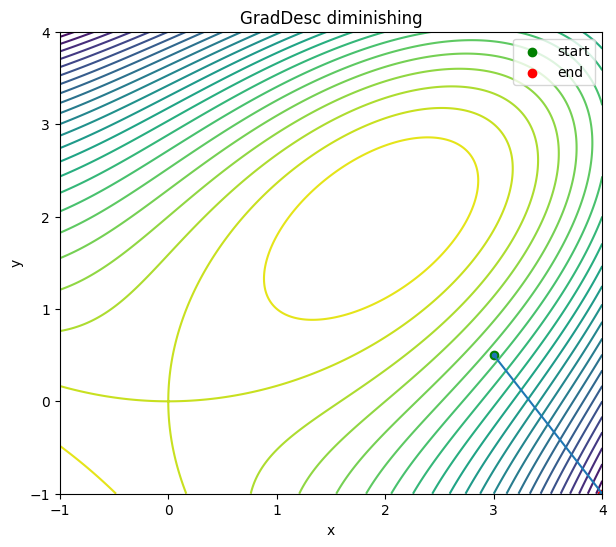

GradDesc backtracking: итераций=20000, x=4.000000, y=-1.000000, f=-87.000000


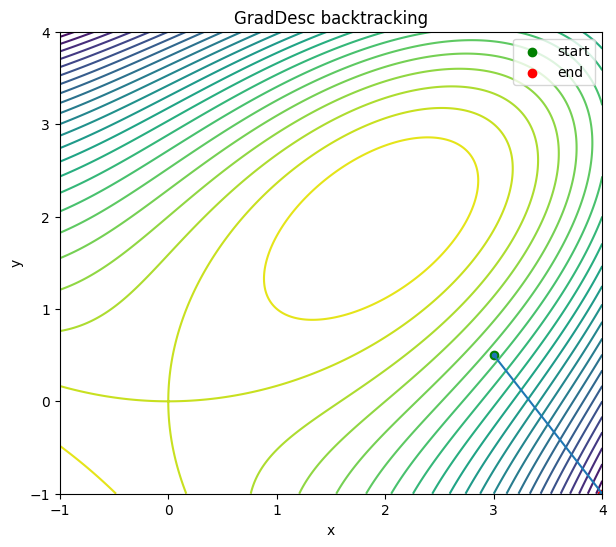

Steepest descent (exact/1D search): итераций=20000, x=4.000000, y=-1.000000, f=-87.000000


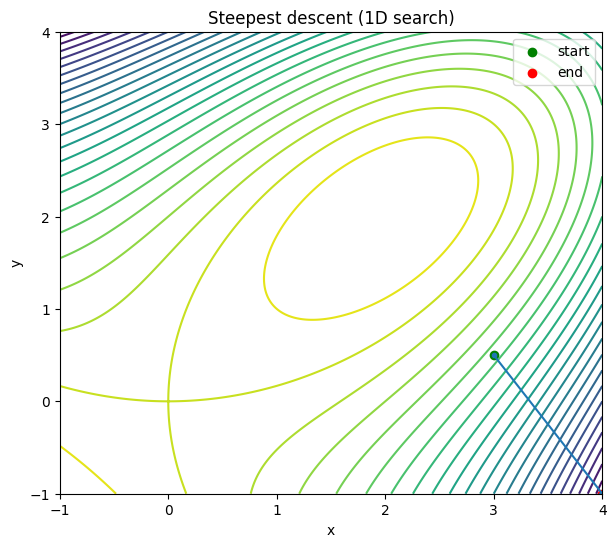

Conjugate FR: итераций=10000, x=nan, y=nan, f=nan


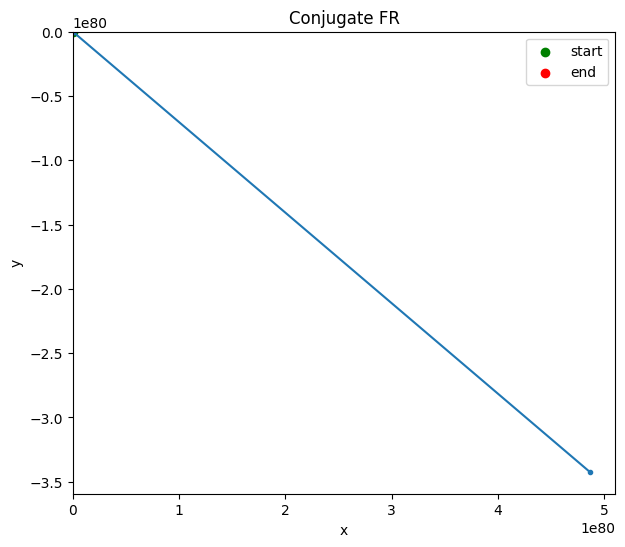

Conjugate PR: итераций=10000, x=nan, y=nan, f=nan


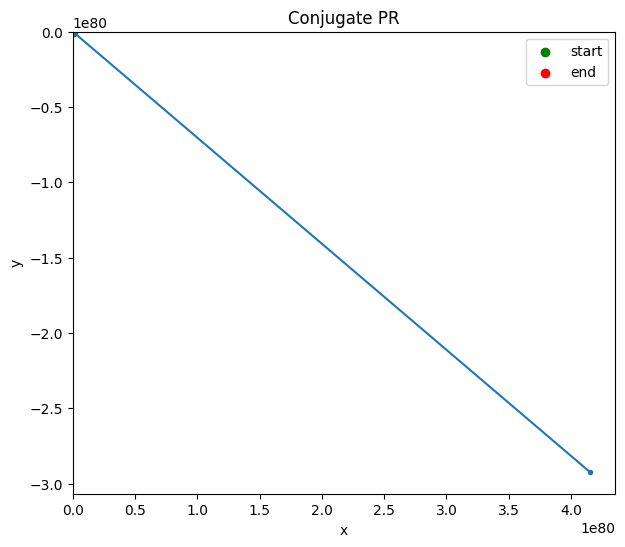


Аналитический максимум: (2,2), f(2,2)=8

--- Автоматическое тестирование (eps = 1e-2 ... 1e-6) для backtracking ---
eps=1e-02  iter=200000  (x,y)=(4.000000,-1.000000)  f=-87.000000  time=0.283s
eps=1e-03  iter=200000  (x,y)=(4.000000,-1.000000)  f=-87.000000  time=0.284s
eps=1e-04  iter=200000  (x,y)=(4.000000,-1.000000)  f=-87.000000  time=0.283s
eps=1e-05  iter=200000  (x,y)=(4.000000,-1.000000)  f=-87.000000  time=0.293s
eps=1e-06  iter=200000  (x,y)=(4.000000,-1.000000)  f=-87.000000  time=0.283s
67

--- Тестирование дополнительных функций ---


== Rosenbrock ==
 backtracking: итераций=14814, x=0.999999, y=0.999998, f=0.000000


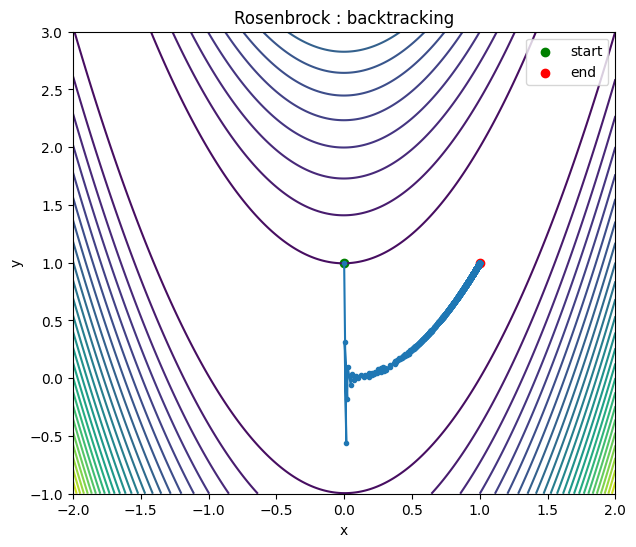

 conjugate PR: итераций=1337, x=1.000000, y=1.000000, f=0.000000

== Rastrigin ==
 backtracking: итераций=0, x=0.000000, y=0.000000, f=0.000000


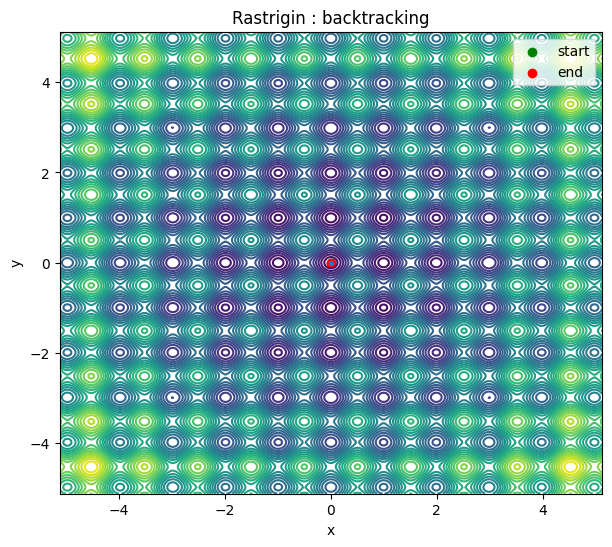

 conjugate PR: итераций=0, x=0.000000, y=0.000000, f=0.000000

== Booth_like (Himmelblau) ==
 backtracking: итераций=25, x=3.000000, y=2.000000, f=0.000000


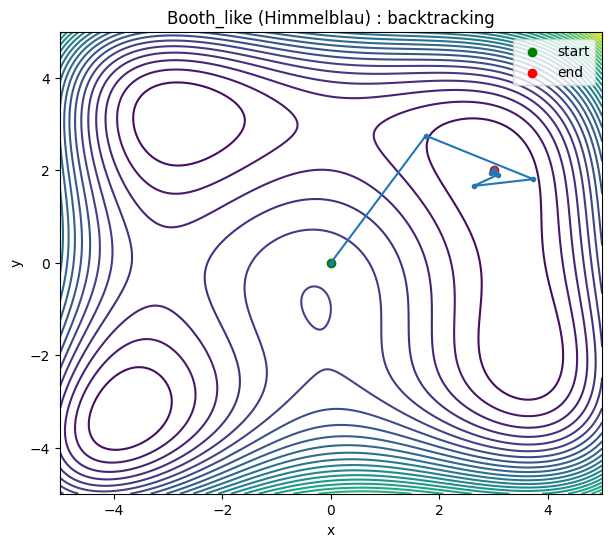

 conjugate PR: итераций=36, x=3.000000, y=2.000000, f=0.000000

== Eggholder * ==
 backtracking: итераций=20000, x=4.000000, y=4.000000, f=-44.996910


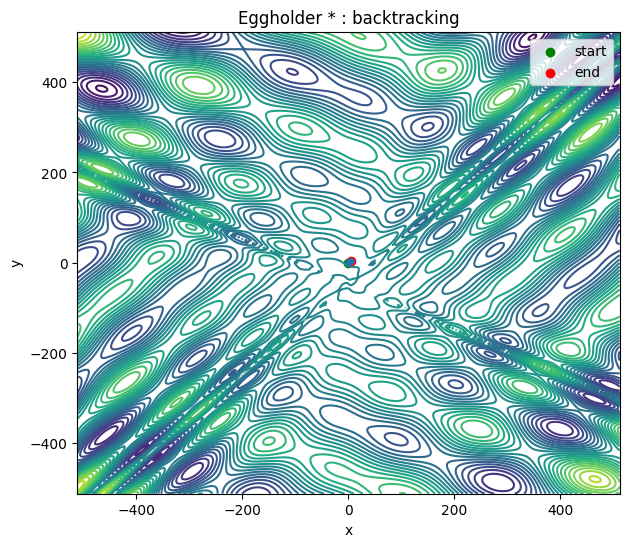

 conjugate PR: итераций=84, x=8.456928, y=15.650920, f=-66.843717

== Bad scale ==
 backtracking: итераций=0, x=0.000000, y=0.000000, f=0.000000


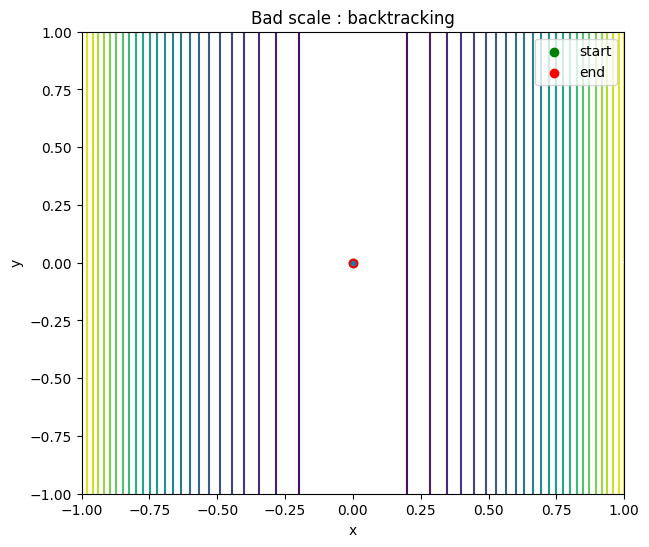

 conjugate PR: итераций=0, x=0.000000, y=0.000000, f=0.000000

== Easom * ==
 backtracking: итераций=0, x=0.000000, y=0.000000, f=-0.000000


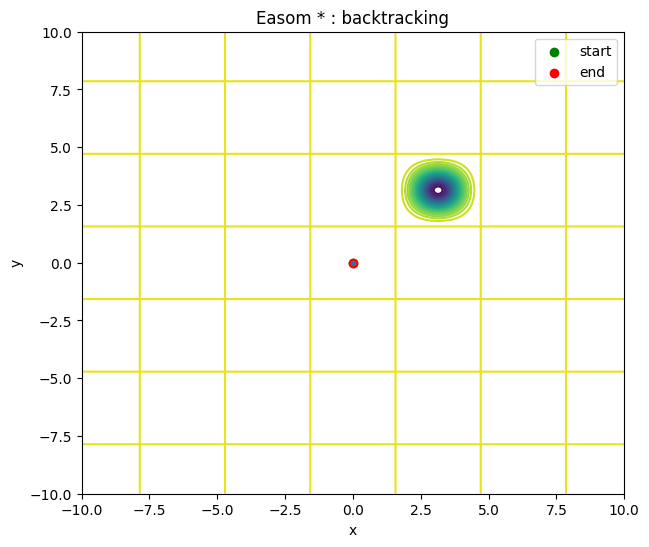

 conjugate PR: итераций=0, x=0.000000, y=0.000000, f=-0.000000

== taskf * ==
 backtracking: итераций=42, x=0.072457, y=0.691485, f=-1.000000


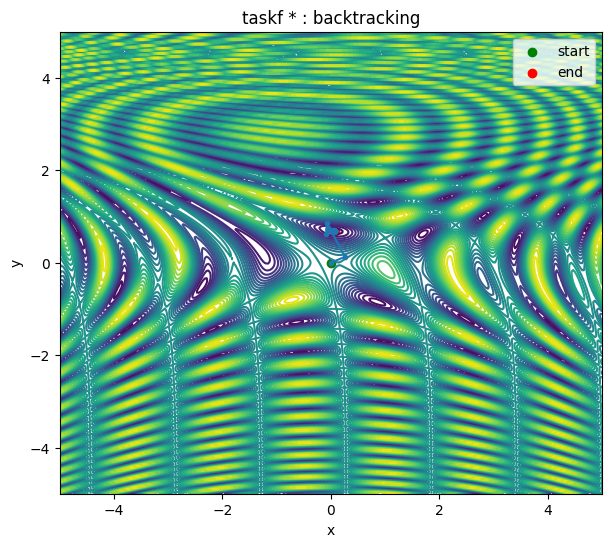

C:\Users\X1mon\AppData\Local\Temp\ipykernel_11376\885280270.py:37: RuntimeWarning: overflow encountered in exp
  return np.sin(x**2 - 3.0*y**2 + 3.0) * np.cos(2.0*x + 1.0 + np.exp(y))
C:\Users\X1mon\AppData\Local\Temp\ipykernel_11376\885280270.py:37: RuntimeWarning: invalid value encountered in cos
  return np.sin(x**2 - 3.0*y**2 + 3.0) * np.cos(2.0*x + 1.0 + np.exp(y))


 conjugate PR: итераций=5000, x=nan, y=nan, f=nan

--- Конец Теста ---



In [ ]:
if __name__ == "__main__":
    x0, y0 = 1.5, 1.5
    eps_list = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    plot_surface_and_contours(f_main, xlim=(-1,4), ylim=(-1,4),
                              mark_points=[(0,0,'red'), (2,2,'blue')],
                              title="f(x,y)=6xy - x^3 - y^3: поверхность и контуры")
    x_c, y_c, hist_c = gradient_descent(f_main, grad_f_main, x0, y0,
                                        alpha_rule=lambda f_, g_, k, x, y, gx, gy: alpha_const(f_, g_, k, x, y, gx, gy, alpha0=0.001),
                                        eps=1e-6, max_iter=20000)
    print_summary("GradDesc constant (alpha=0.01)", x_c, y_c, hist_c)
    plot_trajectory_on_contour(f_main, hist_c, xlim=(-1,4), ylim=(-1,4), title="GradDesc constant")
    x_d, y_d, hist_d = gradient_descent(f_main, grad_f_main, x0, y0,
                                        alpha_rule=alpha_diminishing,
                                        eps=1e-6, max_iter=20000)
    print_summary("GradDesc diminishing", x_d, y_d, hist_d)
    plot_trajectory_on_contour(f_main, hist_d, xlim=(-1,4), ylim=(-1,4), title="GradDesc diminishing")
    x_b, y_b, hist_b = gradient_descent(f_main, grad_f_main, x0, y0,
                                        alpha_rule=alpha_backtracking,
                                        eps=1e-6, max_iter=20000)
    print_summary("GradDesc backtracking", x_b, y_b, hist_b)
    plot_trajectory_on_contour(f_main, hist_b, xlim=(-1,4), ylim=(-1,4), title="GradDesc backtracking")
    x_s, y_s, hist_s = gradient_descent(f_main, grad_f_main, x0, y0,
                                        alpha_rule=None, eps=1e-6, max_iter=20000)
    print_summary("Steepest descent (exact/1D search)", x_s, y_s, hist_s)
    plot_trajectory_on_contour(f_main, hist_s, xlim=(-1,4), ylim=(-1,4), title="Steepest descent (1D search)")
    x_fr, y_fr, hist_fr = conjugate_gradient(f_main, grad_f_main, x0, y0, eps=1e-6, max_iter=10000, variant="FR")
    print_summary("Conjugate FR", x_fr, y_fr, hist_fr)
    plot_trajectory_on_contour(f_main, hist_fr, xlim=(-1,4), ylim=(-1,4), title="Conjugate FR")
    x_pr, y_pr, hist_pr = conjugate_gradient(f_main, grad_f_main, x0, y0, eps=1e-6, max_iter=10000, variant="PR")
    print_summary("Conjugate PR", x_pr, y_pr, hist_pr)
    plot_trajectory_on_contour(f_main, hist_pr, xlim=(-1,4), ylim=(-1,4), title="Conjugate PR")
    print("\nАналитический максимум: (2,2), f(2,2)=8")
    print("\n--- Автоматическое тестирование (eps = 1e-2 ... 1e-6) для backtracking ---")
    rows = []
    for eps in eps_list:
        t0 = time.time()
        x_eps, y_eps, hist_eps = gradient_descent(f_main, grad_f_main, x0, y0, alpha_rule=alpha_backtracking, eps=eps, max_iter=200000)
        t1 = time.time()
        rows.append((eps, len(hist_eps)-1, x_eps, y_eps, hist_eps[-1][2], t1-t0))
        print(f"eps={eps:.0e}  iter={len(hist_eps)-1}  (x,y)=({x_eps:.6f},{y_eps:.6f})  f={hist_eps[-1][2]:.6f}  time={t1-t0:.3f}s")
    print('67')
    print("\n--- Тестирование дополнительных функций ---\n")
    test_funcs = [
        ("Rosenbrock", f_rosenbrock, grad_rosenbrock, (-2, 2, -1, 3)),
        ("Rastrigin", lambda x,y: f_rastrigin(x,y, A=10.0), lambda x,y: grad_rastrigin(x,y, A=10.0), (-5.12, 5.12, -5.12, 5.12)),
        ("Booth_like (Himmelblau)", f_booth_like, grad_booth_like, (-5, 5, -5, 5)),
        ("Eggholder *", f_eggholder, None, (-512, 512, -512, 512)),
        ("Bad scale", f_bad_scale, grad_bad_scale, (-1, 1, -1, 1)),
        ("Easom *", f_easom, None, (-10, 10, -10, 10)),
        ("taskf *", f_taskf, None, (-5,5,-5,5)),
    ]
    for (name, ffun, gfun, bounds) in test_funcs:
        print(f"\n== {name} ==")
        use_num = (gfun is None)
        x0t = (bounds[0] + bounds[1]) / 2.0
        y0t = (bounds[2] + bounds[3]) / 2.0
        x1, y1, h1 = gradient_descent(ffun, gfun, x0t, y0t, alpha_rule=alpha_backtracking, eps=1e-6, max_iter=20000, use_numerical_grad=use_num)
        print_summary(" backtracking", x1, y1, h1)
        try:
            plot_trajectory_on_contour(ffun, h1, xlim=(bounds[0], bounds[1]), ylim=(bounds[2], bounds[3]), title=f"{name} : backtracking")
        except Exception as e:
            print("  (не удалось отрисовать контуры):", e)
        x2, y2, h2 = conjugate_gradient(ffun, gfun, x0t, y0t, eps=1e-6, max_iter=5000, variant="PR", use_numerical_grad=use_num)
        print_summary(" conjugate PR", x2, y2, h2)
    print("\n--- Конец Теста ---\n")
